# Denoising Autoencoder

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from ipywidgets import interact

### Load data

In [3]:
# 1. Load Data
with open('data/final_models_input/train_dataset.pkl', 'rb') as f:
    train_data = pickle.load(f)
    
with open('data/final_models_input/test_dataset.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train_raw = train_data['X'] # Shape: (N, 1500, 4)
X_test_raw = test_data['X']


### Data loading and normalization

In [13]:
tensor_x = torch.tensor(X_train_raw, dtype=torch.float32)  # [N, T, F]
full_dataset = TensorDataset(tensor_x)

val_size = int(len(full_dataset) * 0.15)
train_size = len(full_dataset) - val_size

train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Extract train data
X_train_subset = torch.stack([train_subset[i][0] for i in range(len(train_subset))])
X_train_subset = X_train_subset.numpy()  # back to numpy for sklearn

N_tr, T, F = X_train_subset.shape

# Flatten time dimension
X_train_flat = X_train_subset.reshape(-1, F)

scaler = MinMaxScaler()
scaler.fit(X_train_flat)

X_train_scaled = scaler.transform(X_train_flat).reshape(N_tr, T, F)
X_train_scaled = torch.tensor(X_train_scaled, dtype=torch.float32)

X_val_subset = torch.stack([val_subset[i][0] for i in range(len(val_subset))])
X_val_subset = X_val_subset.numpy()

N_val = X_val_subset.shape[0]
X_val_flat = X_val_subset.reshape(-1, F)

X_val_scaled = scaler.transform(X_val_flat).reshape(N_val, T, F)
X_val_scaled = torch.tensor(X_val_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_scaled)
val_dataset   = TensorDataset(X_val_scaled)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

X_test_flat = X_test_raw.reshape(-1, F)
X_test_scaled = scaler.transform(X_test_flat).reshape(
    X_test_raw.shape[0], T, F
)

X_test_scaled = torch.tensor(X_test_scaled, dtype=torch.float32)


print(f"Data Loaded Successfully.")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Data Loaded Successfully.
Train batches: 33
Val batches: 6


In [14]:
SEQ_LEN = 300
N_FEATURES = 4
BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Define the model

In [5]:
class Encoder(nn.Module):
    def __init__(self, n_features=4, embedding_dim=32): # Reduced embedding to 32
        super(Encoder, self).__init__()
        # Layer 1: 4 -> 64
        self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=64, 
                             num_layers=1, batch_first=True, bidirectional=False)
        # Layer 2: 64 -> 32 (Tight Bottleneck)
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=embedding_dim, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        _, (hidden, _) = self.lstm2(x)
        return hidden[-1]

class Decoder(nn.Module):
    def __init__(self, seq_len, input_dim=32, n_features=4):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        # Layer 1: 32 -> 64
        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=64, 
                             num_layers=1, batch_first=True, bidirectional=False)
        # Layer 2: 64 -> 64
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=64, 
                             num_layers=1, batch_first=True, bidirectional=False)
        # Output: 64 -> 4
        self.output_layer = nn.Linear(64, n_features)

    def forward(self, x):
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = self.output_layer(x)
        return x

class DenoisingAutoencoder(nn.Module):
    def __init__(self, seq_len=300, n_features=4, embedding_dim=32):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = Encoder(n_features, embedding_dim)
        self.decoder = Decoder(seq_len, embedding_dim, n_features)

    def forward(self, x):
        return self.decoder(self.encoder(x))

### Training

Starting Denoising Training...
Epoch 1/100 | Train Loss: 0.001566 | Val Loss: 0.053621
Epoch 2/100 | Train Loss: 0.000697 | Val Loss: 0.034550
Epoch 3/100 | Train Loss: 0.000494 | Val Loss: 0.029137
Epoch 4/100 | Train Loss: 0.000446 | Val Loss: 0.026969
Epoch 5/100 | Train Loss: 0.000425 | Val Loss: 0.026463
Epoch 6/100 | Train Loss: 0.000421 | Val Loss: 0.026464
Epoch 7/100 | Train Loss: 0.000419 | Val Loss: 0.026233
Epoch 8/100 | Train Loss: 0.000417 | Val Loss: 0.026026
Epoch 9/100 | Train Loss: 0.000414 | Val Loss: 0.026006
Epoch 10/100 | Train Loss: 0.000411 | Val Loss: 0.025816
Epoch 11/100 | Train Loss: 0.000411 | Val Loss: 0.025895
Epoch 12/100 | Train Loss: 0.000411 | Val Loss: 0.025741
Epoch 13/100 | Train Loss: 0.000411 | Val Loss: 0.025995
Epoch 14/100 | Train Loss: 0.000408 | Val Loss: 0.025631
Epoch 15/100 | Train Loss: 0.000413 | Val Loss: 0.025883
Epoch 16/100 | Train Loss: 0.000410 | Val Loss: 0.025610
Epoch 17/100 | Train Loss: 0.000408 | Val Loss: 0.025520
Epoch 18/

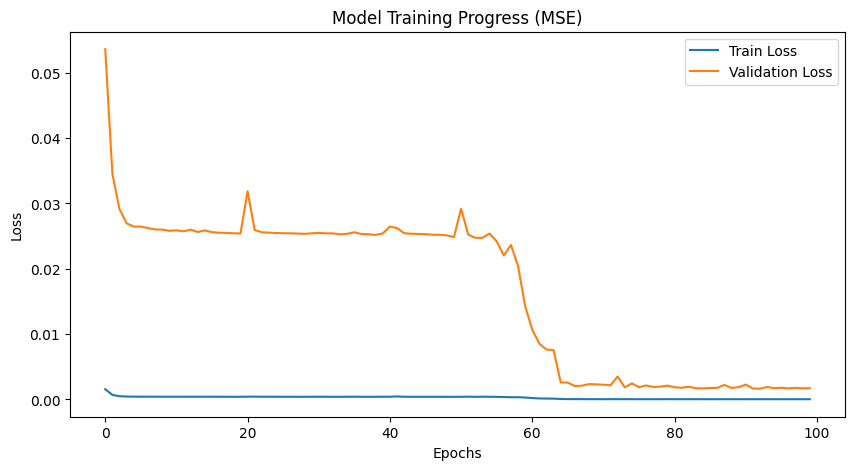

In [10]:
# CONFIG
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoisingAutoencoder(seq_len=1500, n_features=4, embedding_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss() # MSE is fine for DAE

# Training History
history = {'train_loss': [], 'val_loss': []}

# NOISE LEVEL
NOISE_FACTOR = 0.15 # Add 15% random noise during training
EPOCHS = 100

print("Starting Denoising Training...")

for epoch in range(EPOCHS): # Train longer (100 epochs)
    model.train()
    train_loss = 0
    
    for batch in train_loader:
        x_clean = batch[0].to(device)
        
        # 1. Downsample to 300 steps
        # x_clean = x_clean[:, ::5, :] 
        
        # 2. Add Gaussian Noise (The Denoising Step)
        noise = torch.randn_like(x_clean) * NOISE_FACTOR
        x_noisy = x_clean + noise
        
        # 3. Forward Pass (Feed Noisy -> Predict Clean)
        output = model(x_noisy)
        
        # 4. Loss (Compare Output vs Clean)
        loss = criterion(output, x_clean)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            # x = x[:, ::5, :]
            output = model(x)
            loss = criterion(output, x)
            val_loss += loss.item() * x.size(0)
            
    # Calculate Average Losses
    train_loss = train_loss / len(train_subset)
    val_loss = val_loss / len(val_subset)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Training Progress (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

torch.save(model.state_dict(), 'denoising_autoencoder.pth')

In [12]:
# 2. Save Scaler (Important!)
with open('data/final_models_input/denoising_ae_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

### Evaluation/ Validation

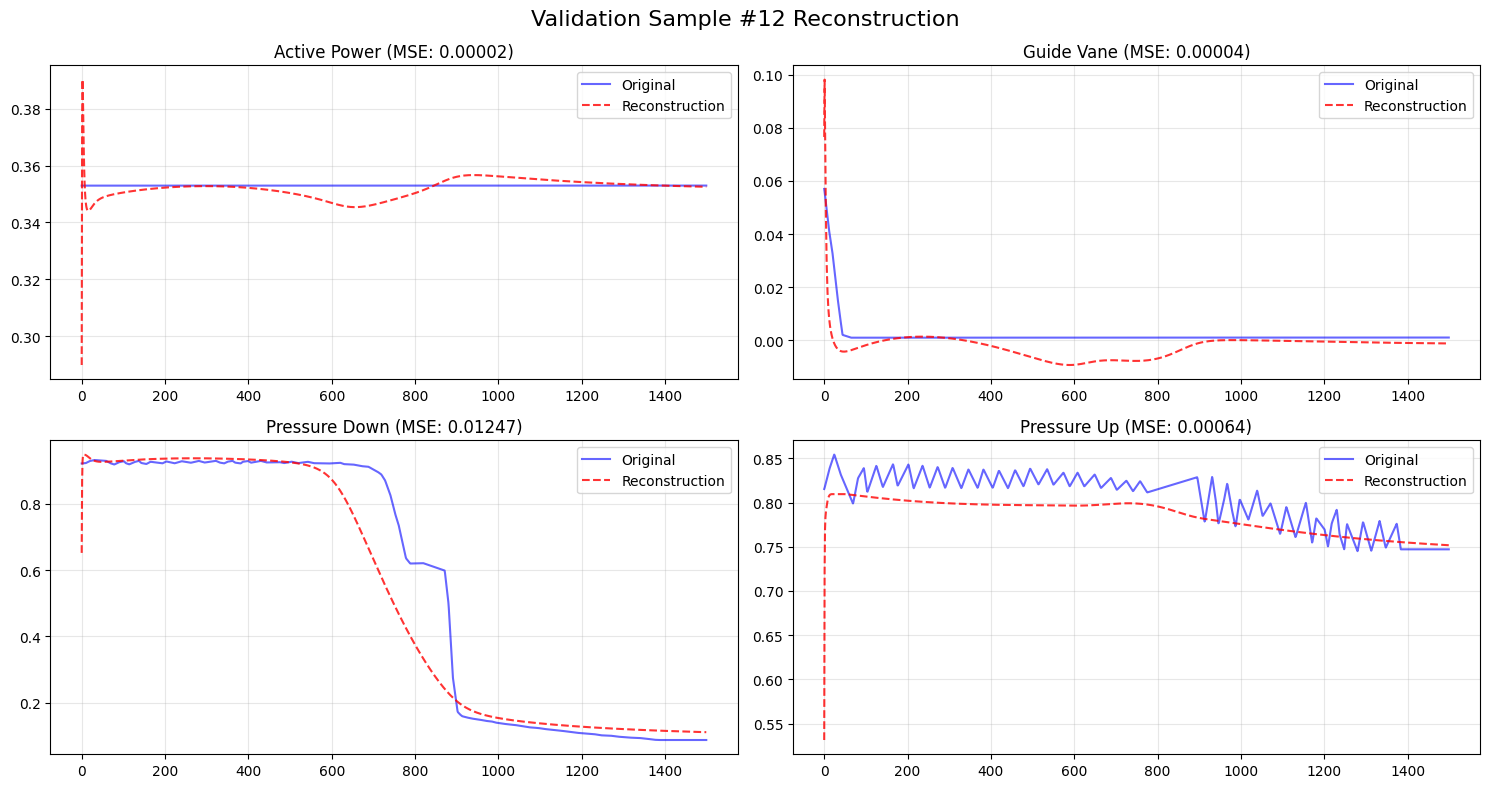

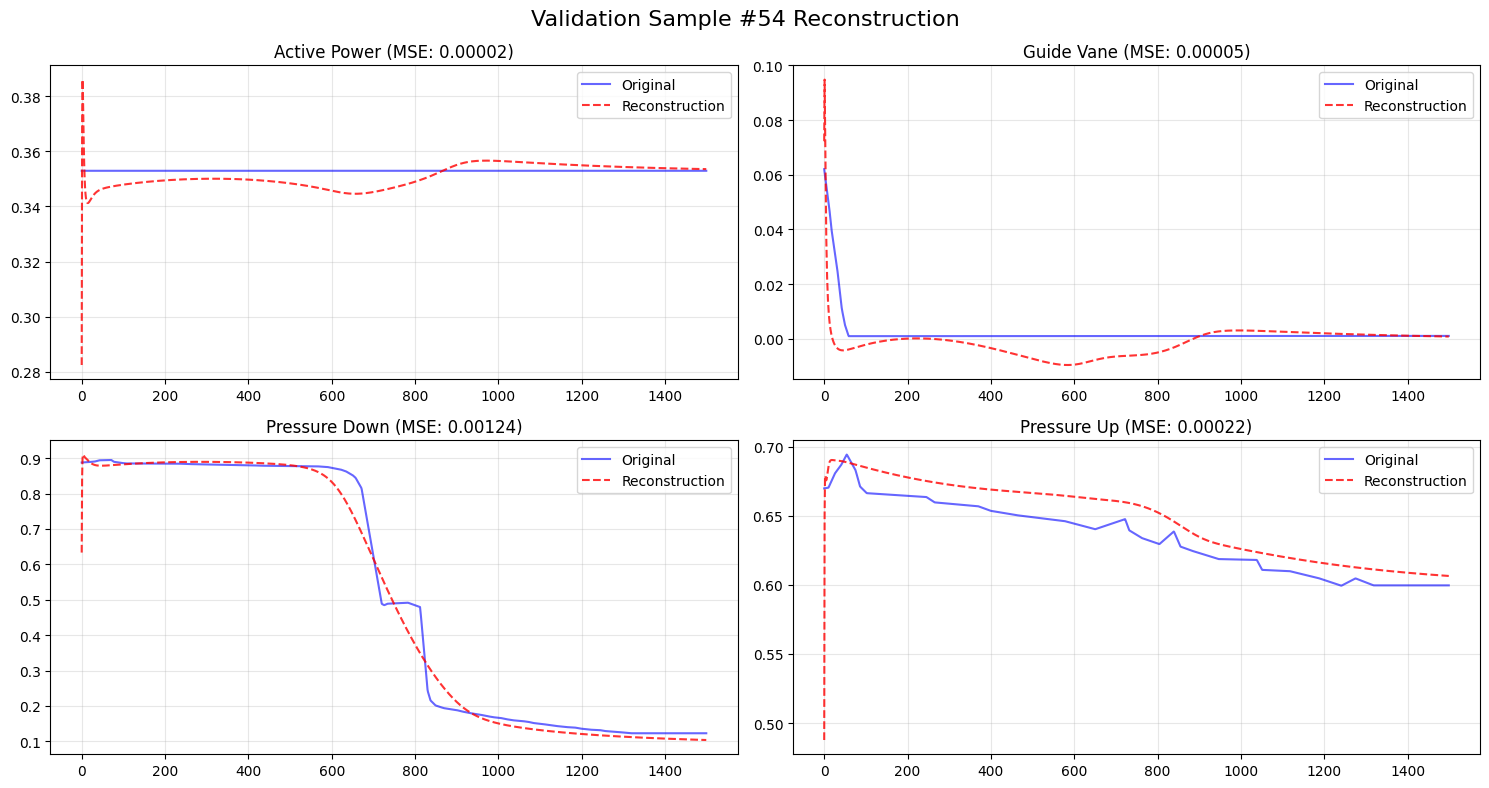

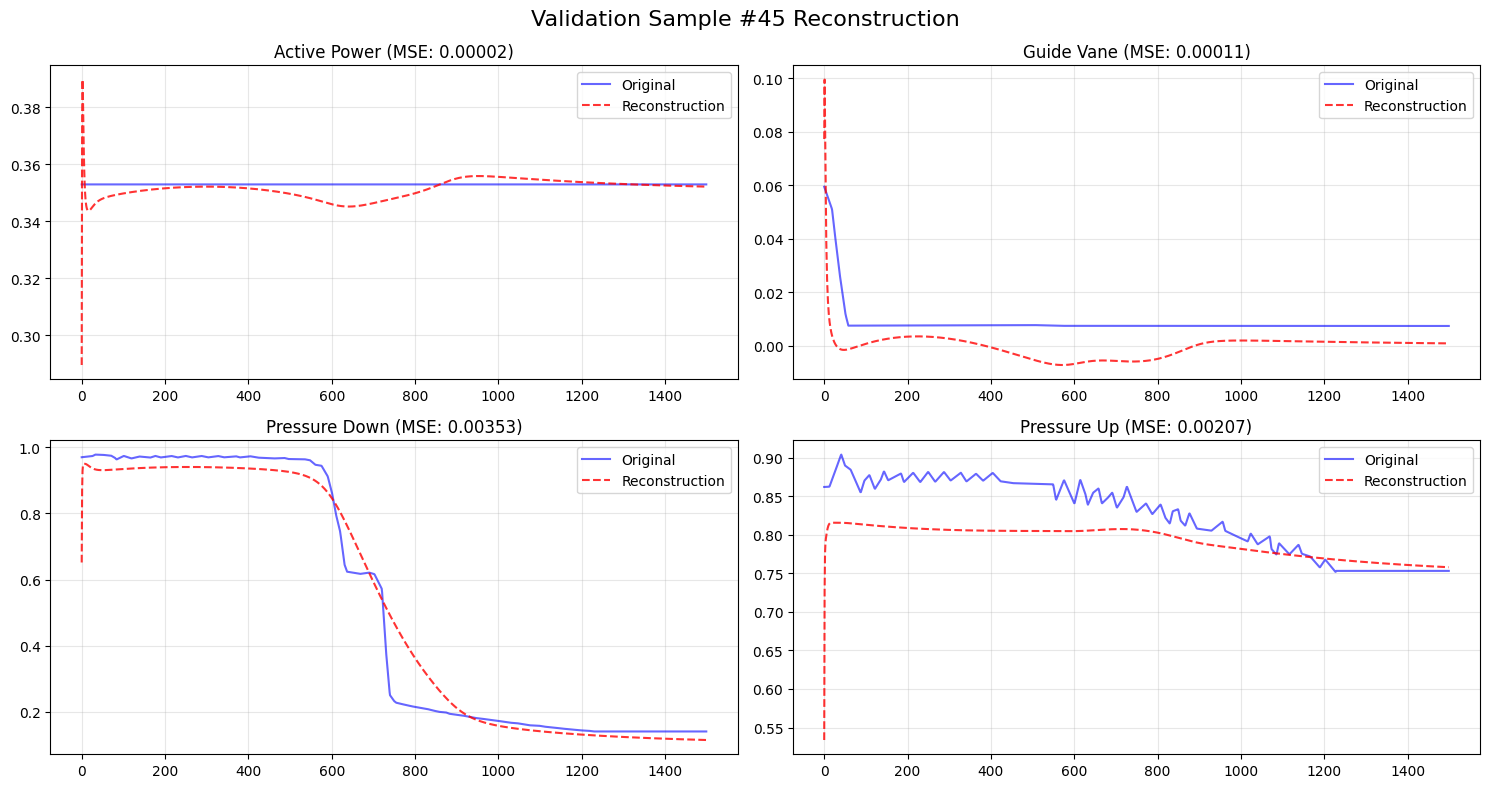

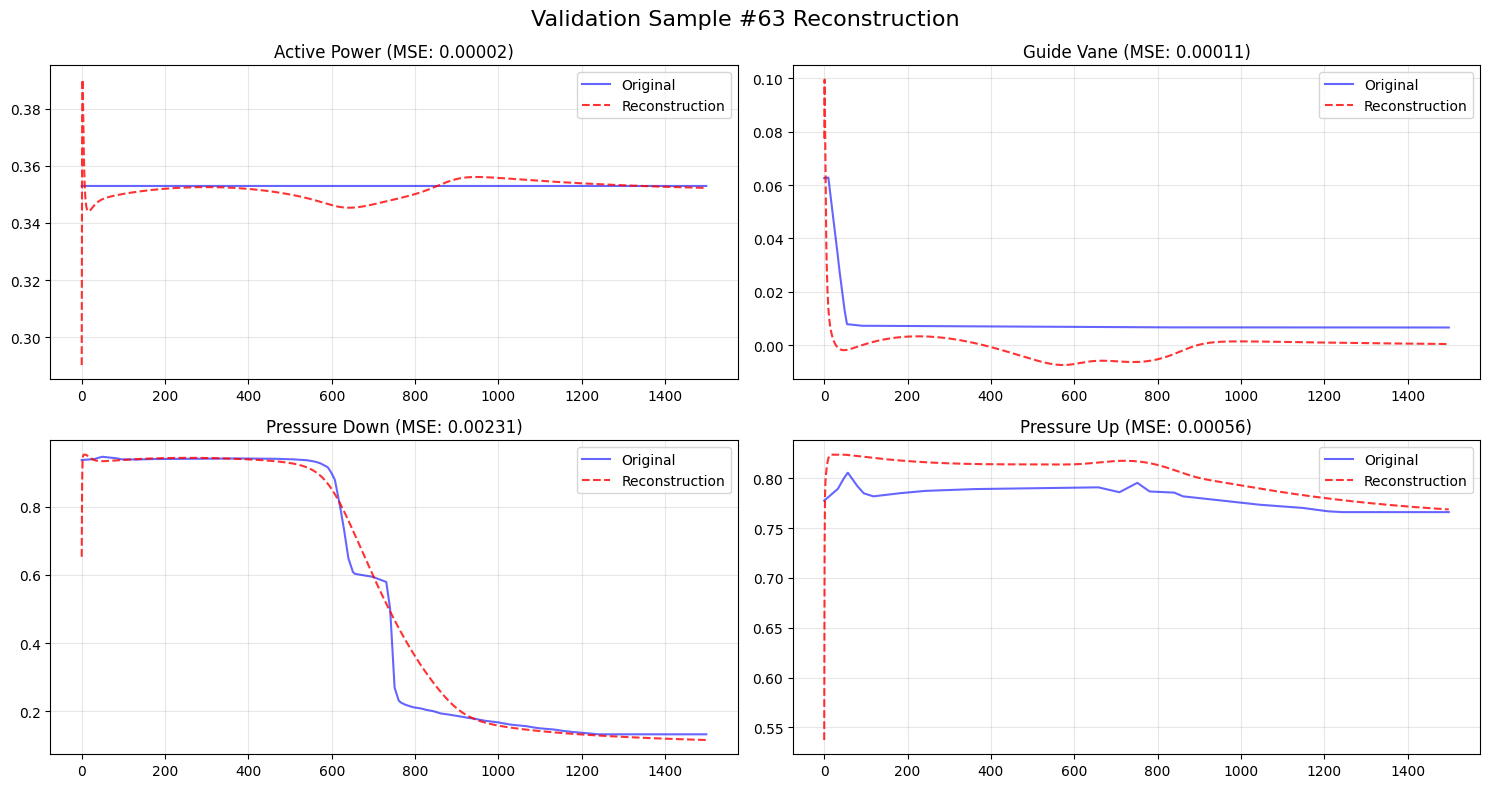

In [11]:
# 1. Get a batch from validation loader
model.eval()
with torch.no_grad():
    x_val_batch = next(iter(val_loader))[0].to(device)
    # x_val_small = x_val_batch[:, ::5, :]
    x_val_small = x_val_batch
    recon_batch = model(x_val_small)
    
    # Move to CPU for plotting
    x_val = x_val_small.cpu().numpy()
    recon = recon_batch.cpu().numpy()

# 2. Plotting Function
def check_reconstruction(idx):
    plt.figure(figsize=(15, 8))
    
    features = ["Active Power", "Guide Vane", "Pressure Down", "Pressure Up"]
    
    for i, name in enumerate(features):
        plt.subplot(2, 2, i+1)
        
        # Plot Original
        plt.plot(x_val[idx, :, i], label='Original', color='blue', alpha=0.6)
        # Plot Reconstruction
        plt.plot(recon[idx, :, i], label='Reconstruction', color='red', linestyle='--', alpha=0.8)
        
        # Calculate Error for this specific feature
        mse_feat = np.mean((x_val[idx, :, i] - recon[idx, :, i])**2)
        plt.title(f"{name} (MSE: {mse_feat:.5f})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
    plt.suptitle(f"Validation Sample #{idx} Reconstruction", fontsize=16)
    plt.tight_layout()
    plt.show()

# 3. Check a few samples
check_reconstruction(12) # Change index to see others
check_reconstruction(54)
check_reconstruction(45)
check_reconstruction(63) 